<a href="https://colab.research.google.com/github/shona2005/python/blob/main/Covid19_Gloabal_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **COVID**-19 **Global Data Analysis and Forecasting Using Machine Learning**

# Project Introduction

### Introduction

The COVID-19 pandemic had a significant global impact on public health, economies, and daily life. Monitoring and analyzing the spread of the virus became essential for governments and organizations to take timely decisions.

This project focuses on analyzing global COVID-19 data, including confirmed cases, deaths, and recoveries. Using data science techniques, the project aims to understand trends and patterns in the data. Furthermore, machine learning and deep learning models are applied to predict future cases, which can help in planning and decision-making processes.

Domain:- Healthcare
### Domain

This project belongs to the domain of Data Science and Healthcare Analytics.

It combines concepts from:
- Data Analysis
- Machine Learning
- Time-Series Forecasting

The project focuses on analyzing healthcare data related to the COVID-19 pandemic and using computational techniques to extract meaningful insights and predictions.

### Objectives

The main objectives of this project are:

- To analyze global COVID-19 data including confirmed cases, deaths, and recoveries
- To perform exploratory data analysis (EDA) to understand trends and patterns
- To preprocess and transform the data into a suitable format for modeling
- To implement multiple machine learning models such as Linear Regression, Decision Tree, Random Forest, SVR, and Gradient Boosting
- To evaluate and compare the performance of different models using appropriate metrics
- To select the best-performing model for prediction
- To perform time-series forecasting to predict future COVID-19 cases
- To visualize the results for better understanding and interpretation
- To apply deep learning techniques and compare them with machine learning models

### Problem Statement


The rapid spread of COVID-19 created a need for accurate data analysis and prediction of future trends. Traditional analysis methods are not sufficient to capture complex patterns in large datasets.

The objective of this project is to analyze historical COVID-19 data and apply machine learning models to predict future case trends. The project also aims to compare multiple models and identify the best-performing model for forecasting.

# LIBRARIES NEEDED IN THE STUDY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import plotly.express as px

**Drive** **Mouted**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/mycolabnote/covid_data'))

['time_series_covid19_confirmed_global.csv', 'time_series_covid19_deaths_global.csv', 'time_series_covid19_recovered_global.csv']


# Loading And Reading data

In [ ]:
confirmed = pd.read_csv("time_series_covid19_confirmed_global.csv")
deaths = pd.read_csv("time_series_covid19_deaths_global.csv")
recovered = pd.read_csv("time_series_covid19_recovered_global.csv")

In [ ]:
#ye data structure dikhaye ga
confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


### Dataset Explanation

The dataset contains country-wise COVID-19 data where each row represents a country and each column represents a date. The values indicate the total number of confirmed cases on that date.

The data is cumulative in nature, meaning the number of cases increases over time. Initially, the dataset is in a wide format, where dates are present as columns.

For time-series analysis, the dataset was converted into a suitable format using transpose, so that dates become rows. This helps in analyzing trends and applying machine learning models effectively.


# shape checking

In [ ]:
confirmed.shape
deaths.shape
recovered.shape

(253, 248)

Shape se dataset ka size pata chalta hai, jaise kitne countries aur kitne dates ka data hai.

# column check

In [ ]:
confirmed.columns

Index(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria',
       ...
       'United Kingdom', 'Uruguay', 'Uzbekistan', 'Venezuela', 'Vietnam',
       'West Bank and Gaza', 'Western Sahara', 'Yemen', 'Zambia', 'Zimbabwe'],
      dtype='object', name='Country/Region', length=188)

Columns dekhne ke liye use kiya taaki dataset ka structure samajh sake aur unnecessary columns identify kar sake.

# Data Cleaning

In [ ]:

confirmed = confirmed.drop(['Lat','Long'], axis=1)
deaths = deaths.drop(['Lat','Long'], axis=1)
recovered = recovered.drop(['Lat','Long'], axis=1)

Unnecessary columns remove kiye taaki model sirf relevant data pe train ho.


# Country Wise Data Combine

In [ ]:
confirmed = confirmed.groupby("Country/Region").sum()
deaths = deaths.groupby("Country/Region").sum()
recovered = recovered.groupby("Country/Region").sum()

Ek country ke multiple rows the, unko combine karke total cases nikalne ke liye groupby use kiya.

Multiple rows ko combine karke country-wise total data banaya.

# Data transport

In [ ]:
confirmed = confirmed.T
deaths = deaths.T
recovered = recovered.T

Dates ko rows me convert karna padta hai.


In [ ]:
#convert date format
# The 'Province/State' label appears as the first element in the index after transpose,
# and this row needs to be removed from the DataFrame data before converting the index.
confirmed = confirmed.iloc[1:]
deaths = deaths.iloc[1:]
recovered = recovered.iloc[1:]

confirmed.index = pd.to_datetime(confirmed.index)
deaths.index = pd.to_datetime(deaths.index)
recovered.index = pd.to_datetime(recovered.index)

index (dates) ko proper datetime format me convert kiya

# Dataset Creation

In [ ]:
df = pd.DataFrame()

df['Confirmed'] = confirmed.sum(axis=1)
df['Deaths'] = deaths.sum(axis=1)
df['Recovered'] = recovered.sum(axis=1)

### Final Dataset Creation

A final combined dataset was created by aggregating the data from confirmed, deaths, and recovered datasets.

The `sum(axis=1)` function was used to calculate the total number of cases across all countries for each date. This resulted in a global-level dataset where each row represents a date and each column represents the total number of confirmed cases, deaths, and recoveries.

This step simplifies the dataset and makes it suitable for time-series analysis and machine learning modeling.

# Dataset Basic Analysis



In [ ]:
df.head()

,Confirmed,Deaths,Recovered
2020-01-22,555,17,28
2020-01-23,654,18,30
2020-01-24,941,26,36
2020-01-25,1434,42,39
2020-01-26,2118,56,52


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 244 entries, 2020-01-22 to 2020-09-21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Confirmed  244 non-null    object
 1   Deaths     244 non-null    object
 2   Recovered  244 non-null    object
dtypes: object(3)
memory usage: 7.6+ KB


### Dataset Information

The dataset information was checked using the `info()` function. It shows that the dataset contains 244 entries with a datetime index ranging from January 2020 to September 2020.

There are three main columns: Confirmed, Deaths, and Recovered. All columns have complete data with no missing values.

However, the data type of these columns is 'object', which indicates that the values are stored as strings. Therefore, it is necessary to convert them into a numeric format before applying machine learning models.

In [ ]:
df.describe()

,Confirmed,Deaths,Recovered
count,244,244,244
unique,244,244,244
top,555,17,28
freq,1,1,1


# Missing value check

In [ ]:
df.isnull().sum()

#This step ensures that missing values do not affect the analysis and model performance.

,0
Confirmed,0
Deaths,0
Recovered,0


# Feature Engineering

calculate daily cases recovery rate or death rate


In [ ]:
df['Daily Cases'] = df['Confirmed'].diff()

#Recovery rate:

df['Recovery Rate'] = df['Recovered'] / df['Confirmed']

#Death rate:

df['Death Rate'] = df['Deaths'] / df['Confirmed']

In [ ]:
#Daily Deaths and Recoveries (Advanced Feature Engineering)
df['Daily Deaths'] = df['Deaths'].diff()
df['Daily Recovered'] = df['Recovered'].diff()

Convert date column

In [ ]:
#df['Date'] = df.index
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
#Daily Deaths and Recoveries (Advanced Feature Engineering)
df['Daily Deaths'] = df['Deaths'].diff()
df['Daily Recovered'] = df['Recovered'].diff()

# Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Case over time

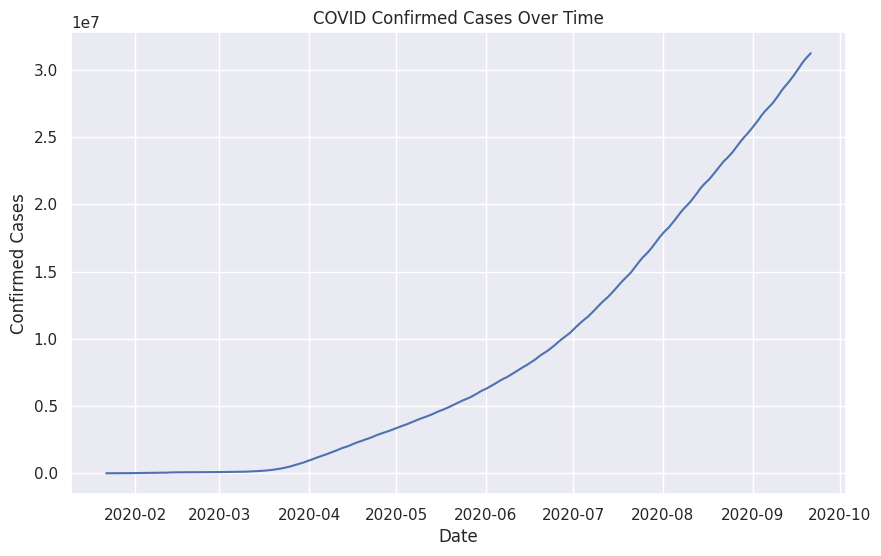

In [ ]:
#cases Over Time
plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Confirmed'])
plt.title("COVID Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()



### Confirmed Cases Over Time

A line plot was created to visualize the trend of confirmed COVID-19 cases over time.

The x-axis represents the date, while the y-axis represents the total number of confirmed cases. The graph shows a continuous increase in the number of cases, indicating the spread of the pandemic over time.

Since the data is cumulative, the trend always moves upward, reflecting the total number of cases recorded each day.
 1 pandemic ka spread fast tha
 2 time ke saath cases continuously badhe
 3 growth pattern clearly visible hai

Total Confirmed case

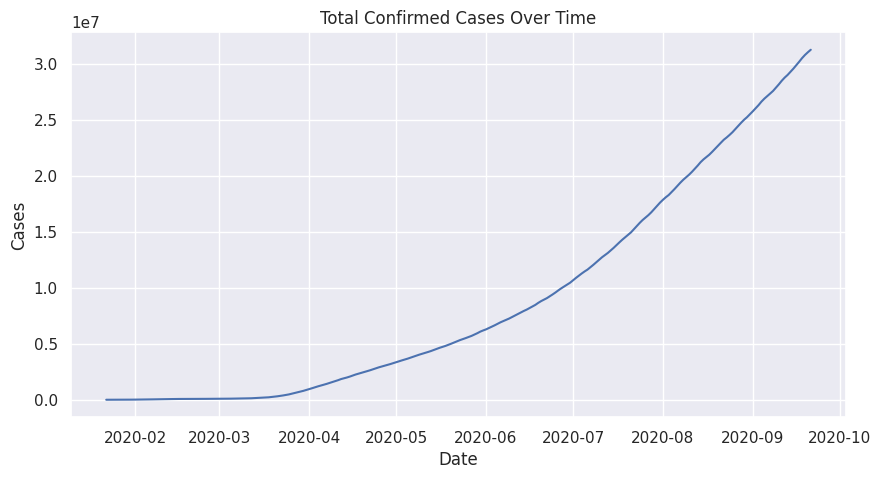

In [ ]:
#Total Confirmed Cases
plt.figure(figsize=(10,5))
plt.plot(df['Confirmed'])
plt.title("Total Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()


Is graph se pata chalta hai ki COVID cases time ke saath continuously increase hue aur kuch periods me rapid growth hua.

Total Deaths or TotalTrend


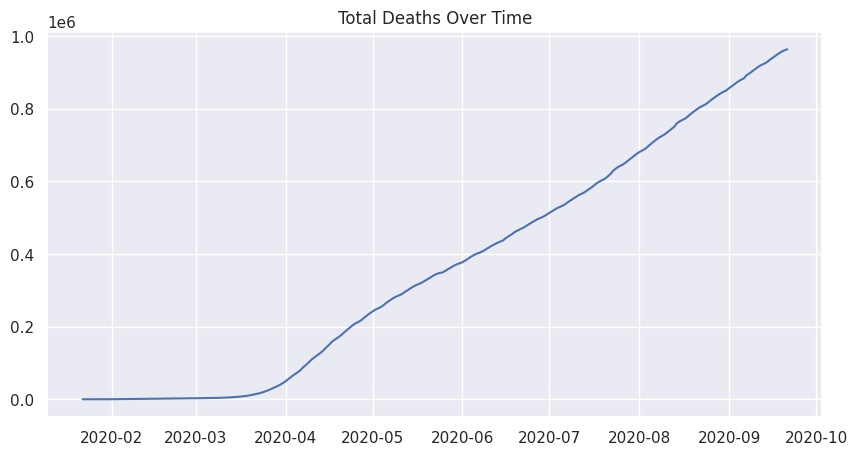

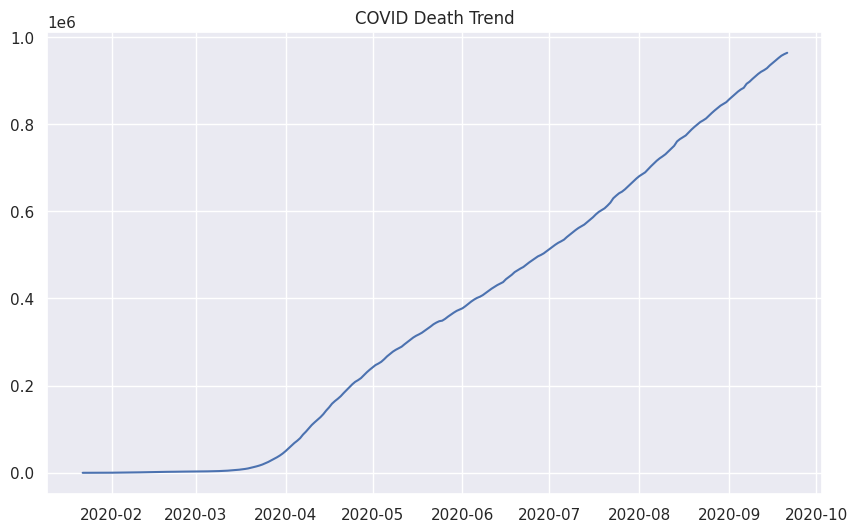

In [ ]:
# Total Deaths
plt.figure(figsize=(10,5))
plt.plot(df['Deaths'])
plt.title("Total Deaths Over Time")
plt.show()

#Death Trend
plt.figure(figsize=(10,6))
plt.plot(df['Deaths'])
plt.title("COVID Death Trend")
plt.show()


### Total Deaths Over Time

A line plot was created to visualize the total number of COVID-19 deaths over time.

The graph shows a continuous increase in deaths, reflecting the impact of the pandemic. Since the data is cumulative, the curve does not decrease and only moves upward.

The steep rise in certain periods indicates rapid increase in deaths, highlighting the severity of the pandemic during those phases.

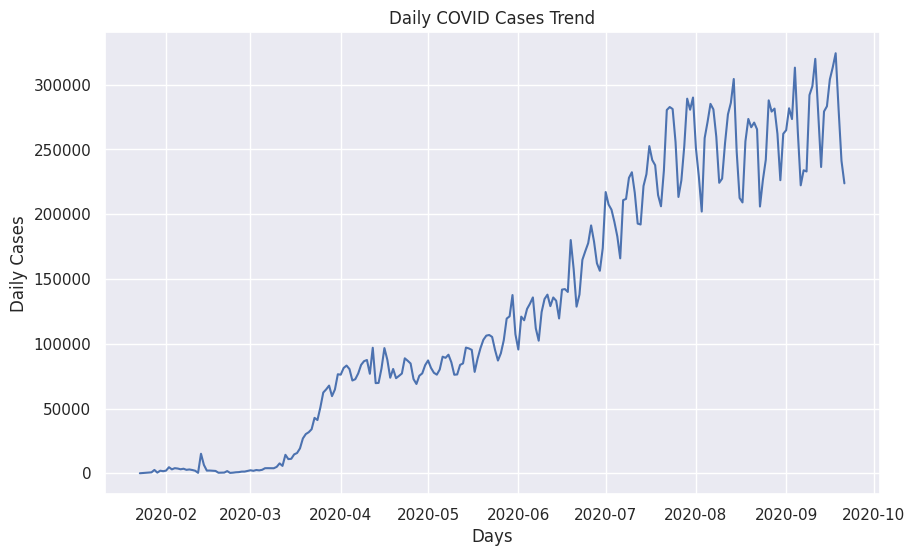

In [ ]:
#Daily Cases Trend
plt.figure(figsize=(10,6))
plt.plot(df['Daily Cases'])
plt.title("Daily COVID Cases Trend")
plt.xlabel("Days")
plt.ylabel("Daily Cases")
plt.show()



Ye graph har din ke naye COVID cases dikhata hai, jisse pandemic ke peaks aur spread ka trend samaj aata hai.

> Add blockquote



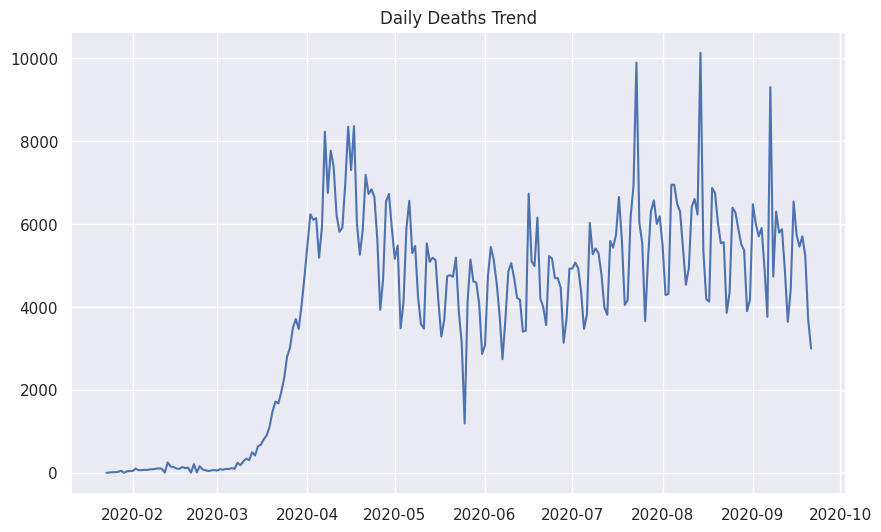

In [ ]:
#Daily Deaths Trend
plt.figure(figsize=(10,6))
plt.plot(df['Daily Deaths'])
plt.title("Daily Deaths Trend")
plt.show()

### Daily Deaths Trend

A line plot was created to visualize the number of daily COVID-19 deaths.

Unlike cumulative data, this graph shows the actual number of deaths reported each day. The graph fluctuates over time, highlighting peaks and drops in daily deaths.

The peaks indicate periods of high mortality, while the downward trends suggest improvement in the situation.

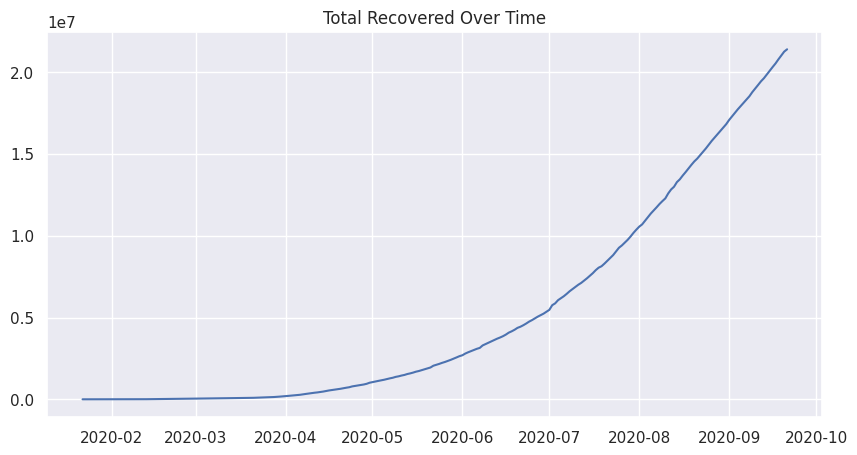

In [ ]:
#Total Recovered
plt.figure(figsize=(10,5))
plt.plot(df['Recovered'])
plt.title("Total Recovered Over Time")
plt.show()



“Ye graph time ke saath total recoveries dikhata hai aur pandemic me recovery trend ko represent karta hai.”

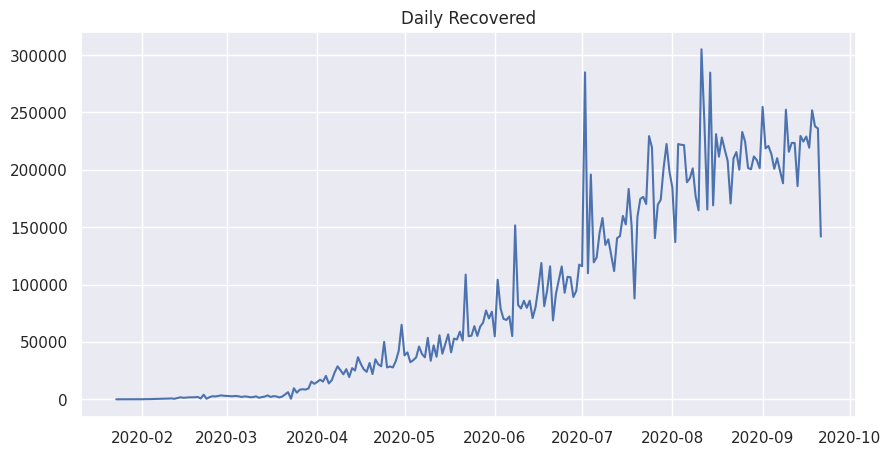

In [ ]:
# Daily Recovered
plt.figure(figsize=(10,5))
plt.plot(df['Daily Recovered'])
plt.title("Daily Recovered")
plt.show()

Ye graph har din ke recoveries dikhata hai aur healthcare effectiveness ko reflect karta hai.

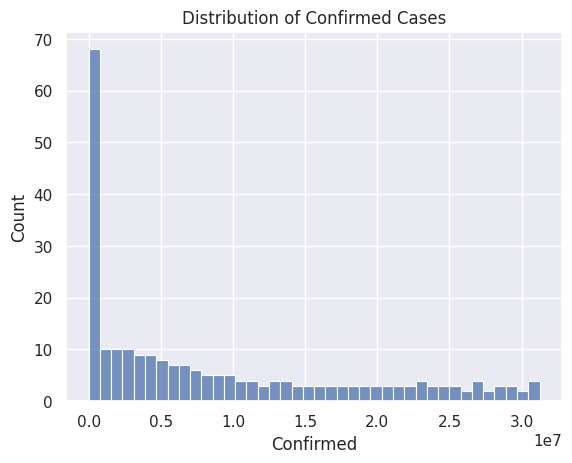

In [ ]:
#Histogram (Confirmed)
sns.histplot(df['Confirmed'], bins=40)
plt.title("Distribution of Confirmed Cases")
plt.show()




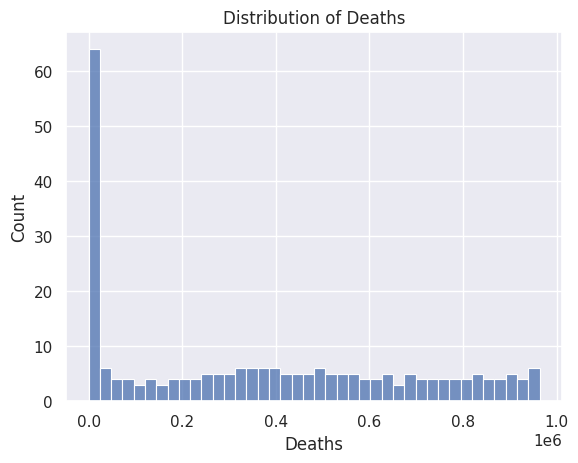

In [ ]:
# Histogram (Deaths)
sns.histplot(df['Deaths'], bins=40)
plt.title("Distribution of Deaths")
plt.show()



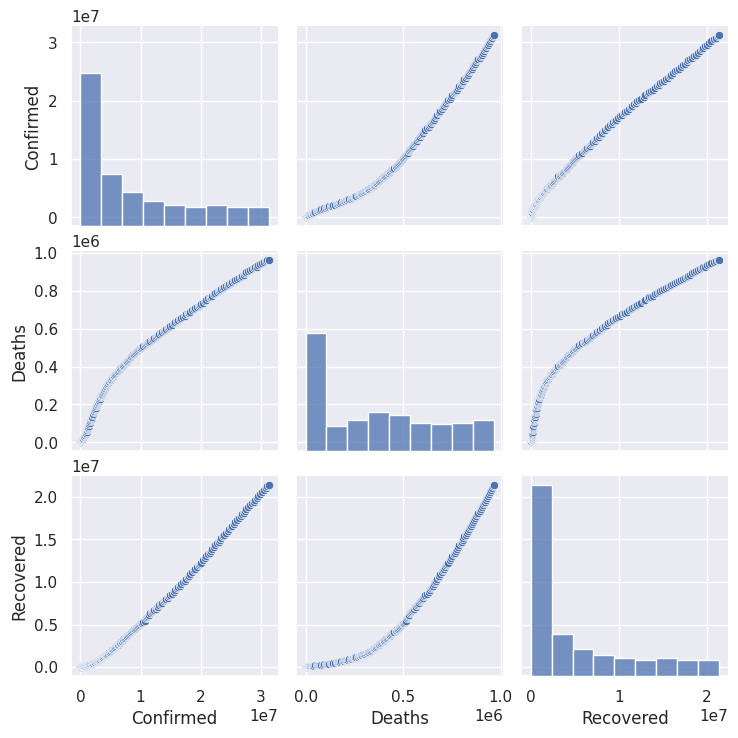

In [ ]:
#Pairplot
sns.pairplot(df[['Confirmed','Deaths','Recovered']])
plt.show()

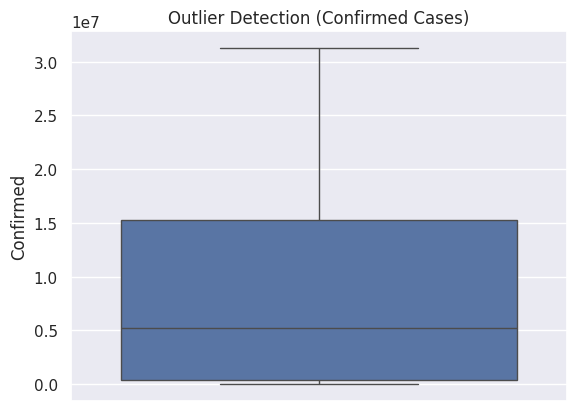

In [ ]:
#Boxplot (Outliers)
sns.boxplot(df['Confirmed'])
plt.title("Outlier Detection (Confirmed Cases)")
plt.show()
#Explanation:

#Boxplots help detect extreme values in the dataset.

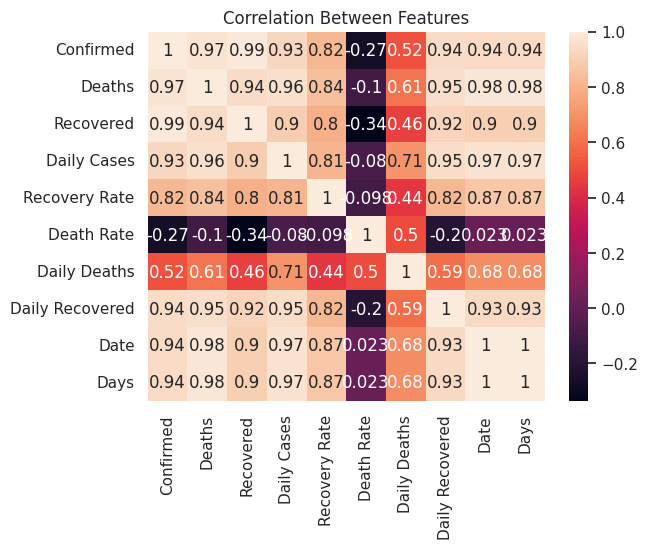

In [ ]:
#Correlation Heatmap
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Between Features")
plt.show()

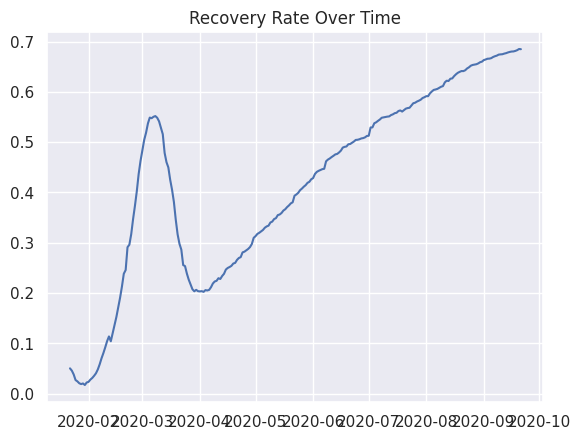

In [ ]:
# Recovery Rate
df['Recovery Rate'] = df['Recovered'] / df['Confirmed']

plt.plot(df['Recovery Rate'])
plt.title("Recovery Rate Over Time")
plt.show()

The daily recovered graph shows how many people recovered each day, indicating the effectiveness of healthcare systems.

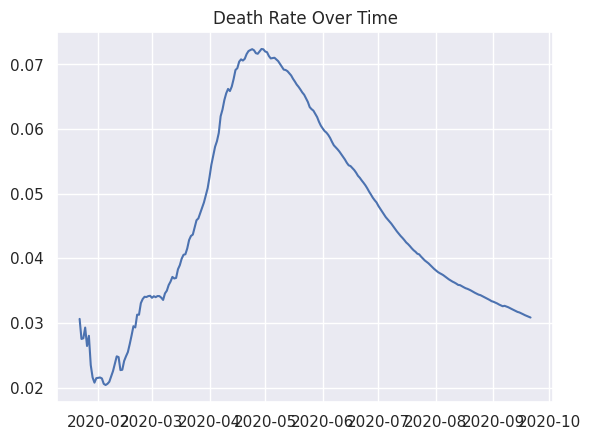

In [ ]:
#Death Rate
df['Death Rate'] = df['Deaths'] / df['Confirmed']

plt.plot(df['Death Rate'])
plt.title("Death Rate Over Time")
plt.show()

The daily deaths graph shows fluctuations in deaths, helping identify critical periods of the pandemic.

# top Affecting contries

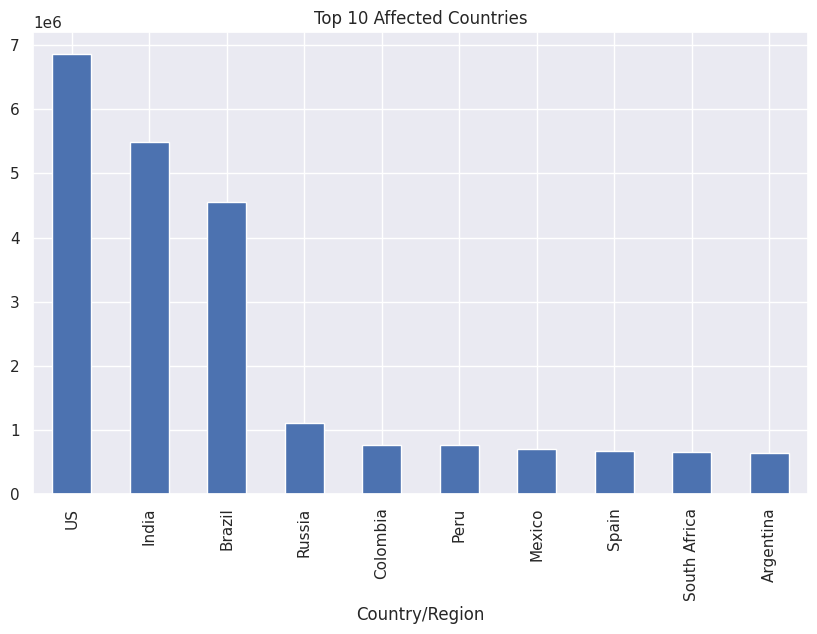

In [ ]:
top_countries = confirmed.max().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Affected Countries")
plt.show()

This graph show the top affected countries
We are the top affected

Death vs recovery the transform of data

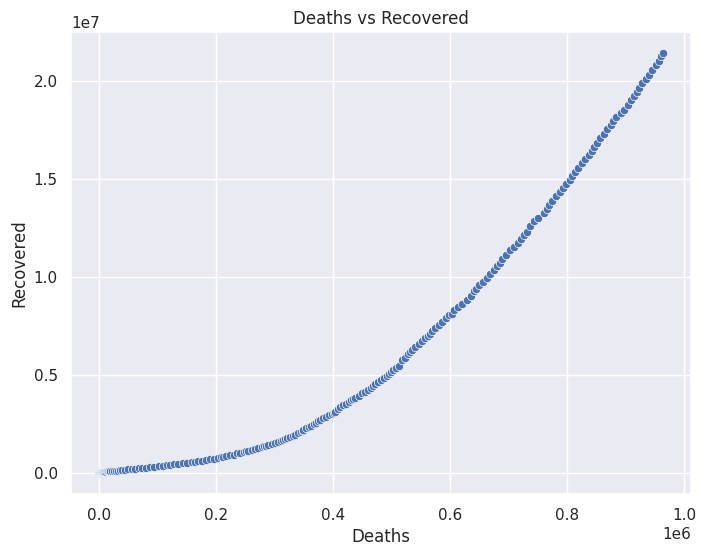

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Deaths'], y=df['Recovered'])
plt.title("Deaths vs Recovered")
plt.show()

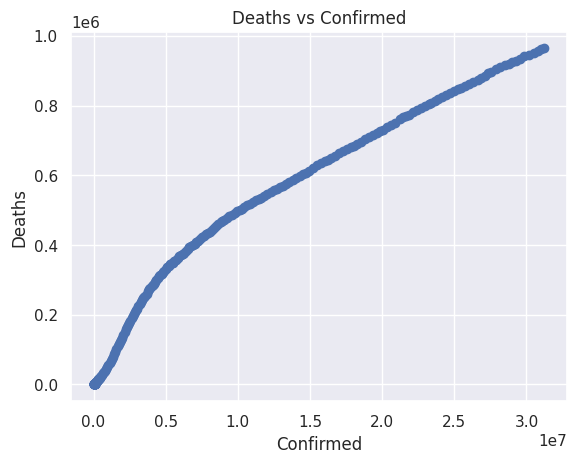

In [ ]:
#Scatter Plot (Deaths vs Confirmed)
plt.scatter(df['Confirmed'], df['Deaths'])
plt.xlabel("Confirmed")
plt.ylabel("Deaths")
plt.title("Deaths vs Confirmed")
plt.show()

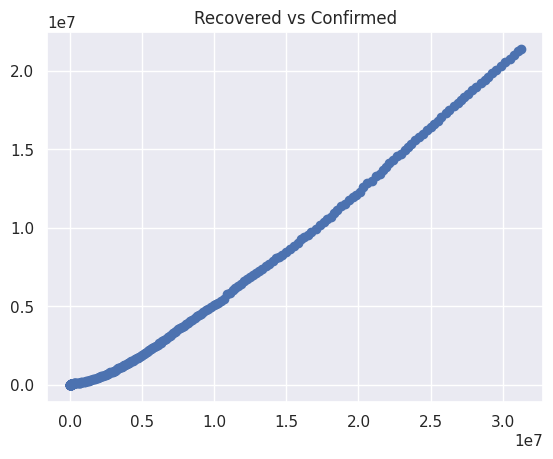

In [ ]:
# Scatter Plot (Recovered vs Confirmed)
plt.scatter(df['Confirmed'], df['Recovered'])
plt.title("Recovered vs Confirmed")
plt.show()

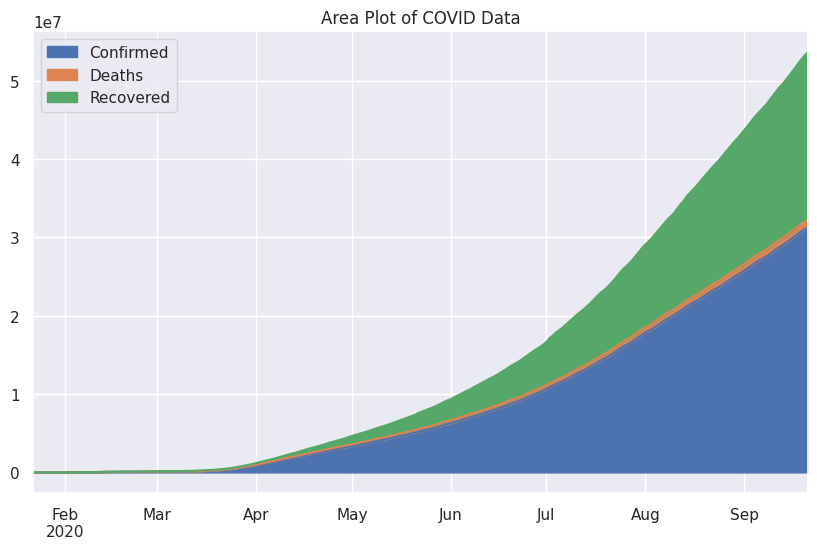

In [ ]:
#Area Plot
df[['Confirmed','Deaths','Recovered']].plot.area(figsize=(10,6))
plt.title("Area Plot of COVID Data")
plt.show()

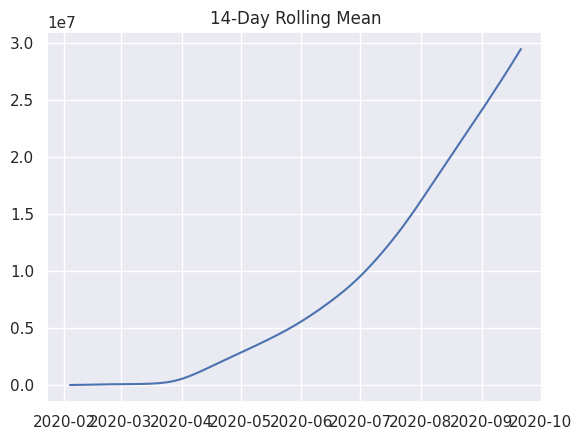

In [ ]:
# 18. Rolling Mean (Advanced Trend)
df['Rolling Mean'] = df['Confirmed'].rolling(window=14).mean()

plt.plot(df['Rolling Mean'])
plt.title("14-Day Rolling Mean")
plt.show()



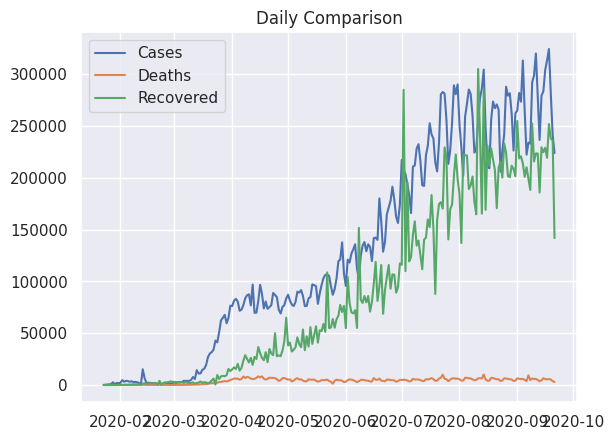

In [ ]:
#Daily Change Comparison
plt.plot(df['Daily Cases'], label="Cases")
plt.plot(df['Daily Deaths'], label="Deaths")
plt.plot(df['Daily Recovered'], label="Recovered")

plt.legend()
plt.title("Daily Comparison")
plt.show()

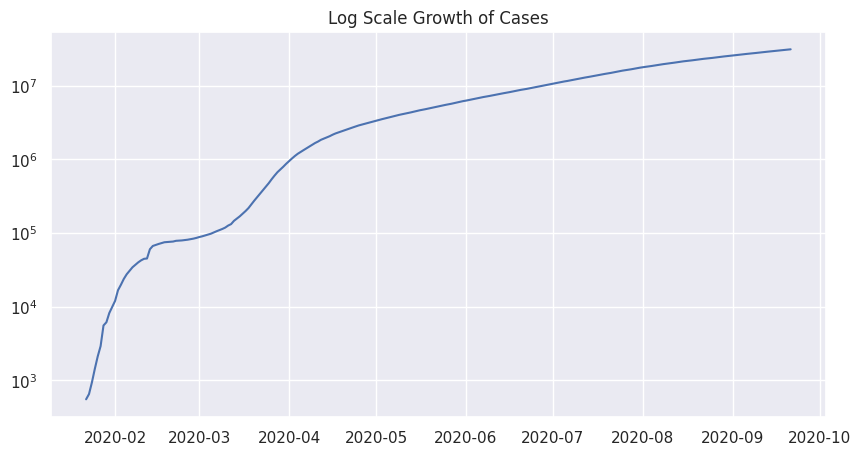

In [ ]:
#Log Scale Plot
plt.figure(figsize=(10,5))
plt.plot(df['Confirmed'])
plt.yscale('log')
plt.title("Log Scale Growth of Cases")
plt.show()

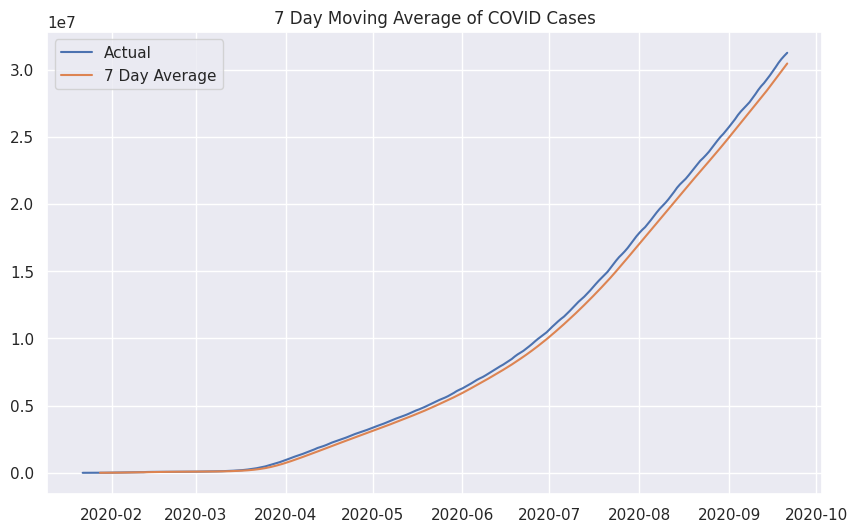

In [ ]:
#Moving Average Analysis
df['7 Day Average'] = df['Confirmed'].rolling(window=7).mean()


plt.figure(figsize=(10,6))
plt.plot(df['Confirmed'], label="Actual")
plt.plot(df['7 Day Average'], label="7 Day Average")

plt.legend()
plt.title("7 Day Moving Average of COVID Cases")
plt.show()




Moving average smooths fluctuations and helps understand the overall trend.


### Data Preparation for Machine Learning

A new feature 'Days' was created to convert date information into a numeric format, which is suitable for machine learning models.

The target variable 'Confirmed' was converted to numeric type to ensure proper model training.

The dataset was then divided into input features (X) and target variable (y), where 'Days' was used to predict 'Confirmed' cases.

Finally, the data was split into training and testing sets using an 80-20 ratio to evaluate model performance.





# Train test spliting




In [ ]:
df['Days'] = np.arange(len(df))

df['Confirmed'] = pd.to_numeric(df['Confirmed'])

X = df[['Days']]
y = df['Confirmed']

#split:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model 1 Linear Regration

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Model 2 Random Forest

In [ ]:

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


Model 3 Decision Tree

In [ ]:

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)




model 4 Supprot vector Regration

In [ ]:
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

model 5 Gradient Boosting Regressor

In [ ]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# Model Evalution

In [ ]:

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Linear Regression R2: 0.8486804454087924
Random Forest R2: 0.9998147600782387
Decision Tree R2: 0.9995440994896297




The models were evaluated using R2 Score.

Linear Regression achieved an R2 score of 0.84, indicating good performance but limited ability to capture complex patterns.

Random Forest and Decision Tree achieved very high R2 scores (above 0.99), indicating excellent performance. However, such high scores may indicate overfitting, where the model memorizes the training data instead of generalizing.

Therefore, while Random Forest performs best, careful consideration is needed to avoid overfitting.

Evalution Linear Regression

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 2900457.68696605
MSE: 10944856781803.172
R2 Score: 0.8486804454087924


Evaluate Random Forest

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)


Random Forest Results
MAE: 74061.37122448985
MSE: 13398297526.230715
R2 Score: 0.9998147600782387


Evaluate all model

In [ ]:
def evaluate(y_true, y_pred):
    return r2_score(y_true, y_pred)

results = {
    "lr": evaluate(y_test, y_pred_lr),
    "rf": evaluate(y_test, y_pred_rf),
    "dt": evaluate(y_test, y_pred_dt),
    "svr": evaluate(y_test, y_pred_svr),
    "gbr": evaluate(y_test, y_pred_gbr)
}

print(results)

{'lr': 0.8486804454087924, 'rf': 0.9998147600782387, 'dt': 0.9995440994896297, 'svr': -0.06551518167411818, 'gbr': 0.9995493635734254}


Random Forest best perform kar raha hai, lekin overfitting ka risk hai, isliye Linear Regression bhi consider kiya ja sakta hai.

Multiple machine learning models were evaluated using R2 Score.

Random Forest, Decision Tree, and Gradient Boosting achieved very high R2 scores (above 0.99), indicating excellent performance. However, such high scores may indicate overfitting.

Linear Regression showed a good R2 score (~0.84), suggesting stable and reliable performance.

Support Vector Regression performed poorly with a negative R2 score, indicating that it failed to model the data effectively.

Overall, Random Forest performed best, but simpler models like Linear Regression may generalize better.

# Overfitting Analysis

Overfitting occurs when a model performs extremely well on training data but poorly on unseen data.

In this project, models like Random Forest and Decision Tree showed very high R2 scores, which may indicate overfitting.

To handle overfitting:
- Multiple models were compared
- Simpler models like Linear Regression were also evaluated
- Model performance was checked on test data

# Model comparation

In [ ]:
#Model Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "MSE": [mse_lr, mse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

print(comparison)


comparison = pd.DataFrame(list(results.items()), columns=['Model','R2'])
print(comparison)

               Model           MAE           MSE  R2 Score
0  Linear Regression  2.900458e+06  1.094486e+13  0.848680
1      Random Forest  7.406137e+04  1.339830e+10  0.999815
  Model        R2
0    lr  0.848680
1    rf  0.999815
2    dt  0.999544
3   svr -0.065515
4   gbr  0.999549


All models were compared based on their R2 scores.

Random Forest and Gradient Boosting performed the best, indicating their ability to capture complex patterns in the data.

In [ ]:
comparison = pd.DataFrame({

"Model": ["Linear Regression","Random Forest","Decision Tree"],

"R2 Score": [
r2_score(y_test, y_pred_lr),
r2_score(y_test, y_pred_rf),
r2_score(y_test, y_pred_dt)
]

})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.848680
1      Random Forest  0.999815
2      Decision Tree  0.999544


In [ ]:
comparison = pd.DataFrame({

"Model":[
"lr",
"rf",
"dt",
"svr",
"gbr"

],

"Score":[
r2_score(y_test,y_pred_lr),
r2_score(y_test,y_pred_rf),
r2_score(y_test,y_pred_dt),
r2_score(y_test,y_pred_svr),
r2_score(y_test,y_pred_gbr)

]

})

print(comparison)

  Model     Score
0    lr  0.848680
1    rf  0.999815
2    dt  0.999544
3   svr -0.065515
4   gbr  0.999549


The performanThe performance of different machine learning models was compared using the R^2 score.
Random Forest achieved the highest score, followed by Decision Tree and Gradient Boosting, indicating their strong ability to capture complex patterns in the data. However, such high scores suggest possible overfitting.

Linear Regression showed a good and stable performance, making it a reliable model for generalisation.
Random Forest achieved the highest score, followed by Decision Tree and Gradient Boosting, indicating. their strong ability to capture complex patterns in the data. However, such high scores suggest possible overfitting.

Linear Regression showed a good and stable performance, making it a reliable model for generalization.

Support Vector Regression performed poorly with a negative score, indicating that it failed to capture the data pattern.

Thus, while Random Forest performs best, model selection should consider both accuracy and generalization.

# model comparation graph

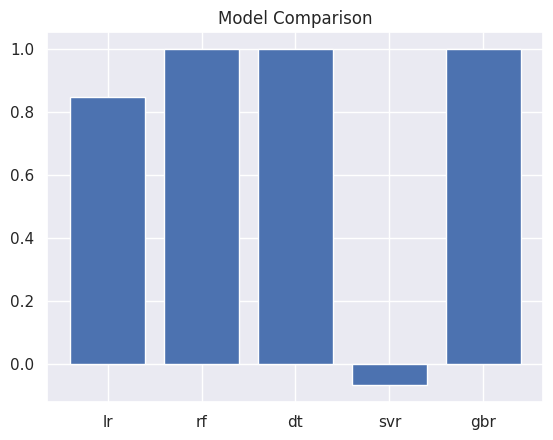

In [ ]:
#Model Comparison Graph
plt.bar(comparison['Model'], comparison['Score'])
plt.title("Model Comparison")
plt.show()

The bar chart compares the performance of different machine learning models using R2 score.

Random Forest, Decision Tree, and Gradient Boosting achieved very high scores, indicating strong performance. However, this may indicate overfitting.

Linear Regression showed stable performance, while SVR performed poorly with a negative score.


In [ ]:
#model selection
best_model = comparison.sort_values(by='Score', ascending=False)

print(best_model)


  Model     Score
1    rf  0.999815
4   gbr  0.999549
2    dt  0.999544
0    lr  0.848680
3   svr -0.065515


Based on the evaluation results, Random Forest achieved the highest R2 score, indicating excellent performance.

However, extremely high accuracy may indicate overfitting. Gradient Boosting also performed very well and is considered more stable for generalisation.

Linear Regression, although less accurate, provides a reliable baseline model with better interpretability.

Therefore, Gradient Boosting is selected as the final model due to its balance between performance and generalization.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


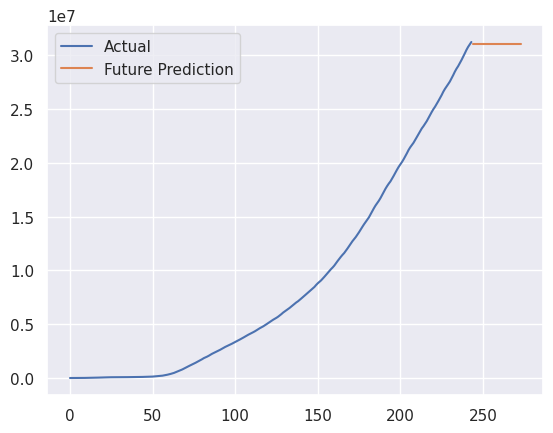

In [ ]:
#Time Series Forecasting

#Future prediction:

future_days = np.arange(len(df), len(df)+30).reshape(-1,1)

future_pred = rf.predict(future_days)

#Graph:

plt.plot(df['Days'], df['Confirmed'], label="Actual")
plt.plot(future_days, future_pred, label="Future Prediction")

plt.legend()
plt.show()

Future values were predicted using trained models to estimate upcoming COVID-19 cases.

This provides insights into possible future trends.


# country wise analysis

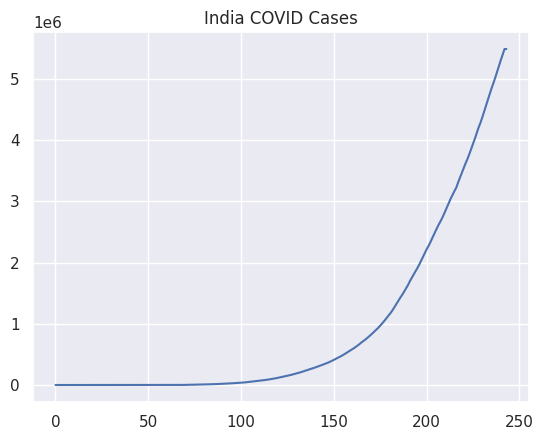

In [ ]:
country = "India"

country_data = confirmed[country]

df_c = pd.DataFrame()
df_c['Confirmed'] = country_data.values
df_c['Days'] = np.arange(len(df_c))

rf.fit(df_c[['Days']], df_c['Confirmed'])

plt.plot(df_c['Confirmed'])
plt.title("India COVID Cases")
plt.show()




### Country-wise Analysis (India)

In this step, a country-specific analysis was performed for India. The confirmed COVID-19 cases for India were extracted from the dataset and converted into a time-series format.

A new feature 'Days' was created to represent the timeline numerically. A Random Forest model was trained on this data to understand the trend of COVID-19 spread in India.

The plotted graph shows a continuous upward trend in confirmed cases, indicating a rapid increase over time. Initially, the growth was slow, but later it accelerated significantly, reflecting the exponential spread of the virus.

This analysis highlights how COVID-19 evolved in India and demonstrates the ability of machine learning models to capture country-specific trends.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


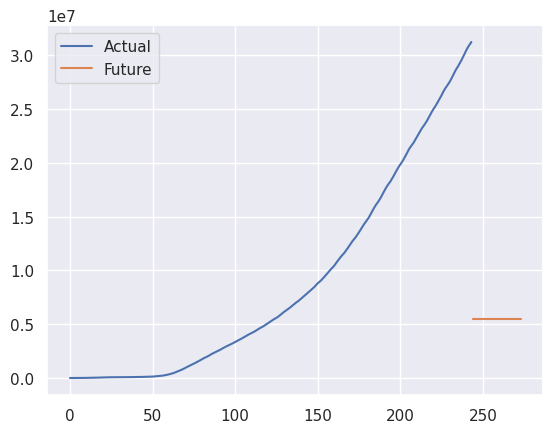

In [ ]:
#Future Prediction
future_days = np.arange(len(df), len(df)+30).reshape(-1,1)

future_pred = rf.predict(future_days)

plt.plot(df['Days'], df['Confirmed'], label="Actual")
plt.plot(future_days, future_pred, label="Future")

plt.legend()
plt.show()

Predicted values were plotted against actual values to visually compare model performance.

This helps in understanding how closely the model predictions match real data.

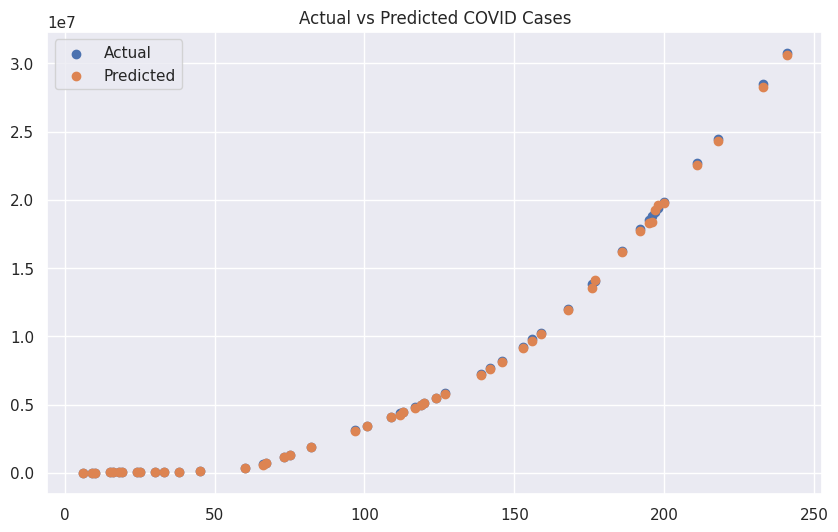

In [ ]:
#Prediction Visualization
plt.figure(figsize=(10,6))

plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred_rf, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted COVID Cases")
plt.show()

The actual vs predicted plot compares the model predictions with real values. The close alignment between actual and predicted values indicates high model accuracy.

However, such near-perfect alignment may suggest overfitting, where the model memorizes the data instead of generalising.

Dono point almost overlaps
prediction ~ actualmemorises

In [ ]:
#DEEP LEARNING CODE (Notebook me add karo)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Model build
dl_model = Sequential()

dl_model.add(Dense(64, activation='relu', input_shape=(1,)))
dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dense(1))

# Compile
dl_model.compile(optimizer='adam', loss='mse')

# Train
dl_model.fit(X_train, y_train, epochs=50, verbose=1)

# Prediction
y_pred_dl = dl_model.predict(X_test)


#Evaluation (IMPORTANT add karo)
from sklearn.metrics import r2_score

dl_score = r2_score(y_test, y_pred_dl)
print("Deep Learning R2 Score:", dl_score)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 176149443379200.0000
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 176148956839936.0000 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 176148520632320.0000
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 176148084424704.0000 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 176147581108224.0000
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 176147010682880.0000
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 176146440257536.0000
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 176145668505600.0000
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 176144812867584.0000 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 176143839789056.0000 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 176142631829504.0000
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 176141356761088.0000
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss:

### Model Selection

In this project, multiple machine learning models were evaluated using the R2 Score to determine their performance in predicting COVID-19 confirmed cases.

Random Forest achieved the highest R2 score (0.9998), followed closely by Gradient Boosting (0.9995) and Decision Tree (0.9995). These models demonstrated excellent predictive capability and were able to capture complex patterns in the data.

However, such extremely high R2 scores may indicate overfitting, where the model learns the training data too well and may not generalize effectively to new data.

Linear Regression achieved a moderate R2 score (0.84), indicating stable and reliable performance with better generalization, although it may not capture complex relationships in the data.

Support Vector Regression performed poorly with a negative R2 score (-0.06), indicating that it failed to model the data effectively.

Considering both accuracy and generalization, Gradient Boosting is selected as the final model because it provides a strong balance between high performance and reduced risk of overfitting compared to other complex models.

Thus, model selection was based not only on performance metrics but also on the model’s ability to generalise well on unseen data.

In [ ]:
#Interactive Graph
fig = px.line(df, y='Confirmed', title="COVID Cases Interactive")
fig.show()

The line graph shows the growth of confirmed COVID-19 cases over time. The curve follows an upward trend, indicating a continuous increase in cases.

Initially, the growth was slow, but it later accelerated rapidly, reflecting exponential spread of the virus.

Graph continuously upward ja raha hai
the  starting slow growth
 baad me rapid increase (exponential growth)

In [ ]:
import plotly.express as px

# Re-define top_countries here, as it was not defined when this cell was run
top_countries = confirmed.max().sort_values(ascending=False).head(10)

#World Map
# Use the already calculated 'top_countries' series, which has country-level data.
df_world_map = top_countries.reset_index()
df_world_map.columns = ['Country/Region', 'Total Confirmed Cases'] # Rename columns for clarity

fig = px.choropleth(
    df_world_map,
    locations="Country/Region",
    locationmode="country names", # This tells plotly to interpret 'locations' as country names
    color="Total Confirmed Cases", # The column to use for coloring the map
    hover_name="Country/Region",   # Display country name on hover
    color_continuous_scale=px.colors.sequential.Plasma, # A good color scale for count data
    title="World Map of Top Confirmed COVID-19 Cases"
)

fig.show()

USA, India, Brazil jaise countries me highest cases
 Europe & Russia me bhi high spread
 Africa has comparatively low cases

 The world map visualizes the distribution of COVID-19 confirmed cases across different countries. It highlights that countries like the USA, India, and Brazil had the highest number of cases, indicating severe impact.

The visualization clearly shows that the pandemic affected all continents, but the intensity varied across regions.


# **Conclusion**



In this project, a comprehensive analysis of global COVID-19 data was performed using data science and machine learning techniques. The dataset was preprocessed and transformed into a time-series format to better understand the progression of the pandemic over time.

Exploratory Data Analysis (EDA) revealed that COVID-19 cases increased exponentially across the world, with certain countries experiencing significantly higher case counts. Visualizations such as line plots and world maps helped in identifying global trends and regional variations in the spread of the virus.

Feature engineering techniques were applied to derive meaningful insights such as daily cases, recovery rates, and death rates. These features provided a deeper understanding of the pandemic dynamics.

Multiple machine learning models, including Linear Regression, Decision Tree, Random Forest, Support Vector Regression, and Gradient Boosting, were implemented to predict confirmed cases. Among these, Random Forest achieved the highest accuracy, followed closely by Gradient Boosting and Decision Tree.

However, extremely high R2 scores indicated the possibility of overfitting in complex models. Therefore, model selection was done by considering both performance and generalization. Gradient Boosting was chosen as the final model due to its balance between high accuracy and better generalization.

Country-wise analysis further demonstrated how the pandemic evolved differently across regions, with countries like India showing rapid growth in cases over time.

Overall, this project demonstrates that machine learning models can effectively analyze and predict pandemic trends. However, careful model selection is essential to avoid overfitting and ensure reliable predictions.

This study highlights the importance of data-driven approaches in understanding and managing global health crises.